# Inference — High Neutrino Purity Data
ROOT file: `ttree_analysis_PosRecoCVNNuSlice-20260227T191304.root`

| TTree | Entries | Contenido |
|-------|---------|----------|
| `opanatree/inference_tree` | 614 | Predicciones ResNet (eventos que pasaron filtros) |
| `nusliceana/nuslicetree` | 5000 | Info Pandora slice + predicciones CNN (todos los eventos) |

In [1]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import curve_fit

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

ROOT_FILE = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_DATA/prueba_v_old/ttree_analysis_PosRecoCVNNuSlice-20260420T100449.root'
PLACEHOLDER = -900
FV_X = (-180.0, 180.0)
FV_Y = (-185.0, 185.0)
FV_Z = (  10.0, 490.0)

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)

## 1. Cargar TTrees

In [2]:
f = uproot.open(ROOT_FILE)

df_inf      = f['ResNetInference/inference_tree'].arrays(library='pd')
df_slice  = f['nusliceana/nuslicetree'].arrays(library='pd')

print(f'inference_tree : {len(df_inf):>5} eventos')
print(f'nuslicetree    : {len(df_slice):>5} eventos')
display(df_inf.head(3))
display(df_slice.head(3))

inference_tree :    19 eventos
nuslicetree    :   100 eventos


,run,subrun,event,passed_filters,pred_x,pred_y,pred_z,selected_tpc,pred_dir_y,pred_dir_z
0,18542,1,190893,True,85.429168,-69.389427,428.343773,0,0.147968,0.988992
1,18542,1,191025,True,178.086889,-136.295366,476.764441,0,-0.756876,0.653559
2,18542,1,191531,True,105.681658,-145.628977,280.764759,1,0.343524,0.939144


,run,subrun,event,sliceID,sliceNuScore,vtxX,vtxY,vtxZ,spBaryX,spBaryY,...,spPCAv2x,spPCAv2y,spPCAv2z,spPCAv3x,spPCAv3y,spPCAv3z,nSpacePoints,cnnPredX,cnnPredY,cnnPredZ
0,18542,1,190651,-1,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,0,-999.0,-999.0,-999.0
1,18542,1,190673,-1,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,0,-999.0,-999.0,-999.0
2,18542,1,190783,-1,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,0,-999.0,-999.0,-999.0


## 2. Cutflow — eficiencia de cada filtro

El `NuSliceAnalyzer` almacena **−999** cuando el evento no pasa la selección neutrino.  
Los cortes is_clear_cosmic, NuScore < 0.6 y FV no son separables en este ROOT file: todos producen −999.

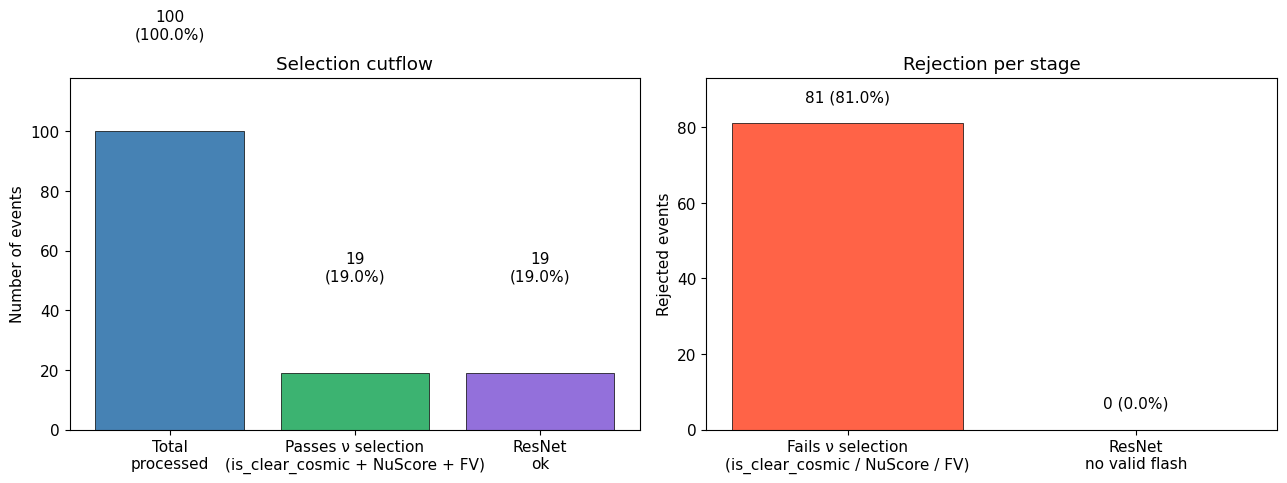

Total efficiency: 19/100 = 19.0%


In [3]:
n_total  = len(df_slice)
n_selec  = (df_slice['sliceNuScore'] > PLACEHOLDER).sum()   # passes neutrino selection
n_resnet = (df_inf['pred_x'] > PLACEHOLDER).sum()           # ResNet produced valid prediction

labels = ['Total\nprocessed', 'Passes ν selection\n(is_clear_cosmic + NuScore + FV)', 'ResNet\nok']
counts = [n_total, n_selec, n_resnet]
colors = ['steelblue', 'mediumseagreen', 'mediumpurple']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cumulative bars
bars = axes[0].bar(labels, counts, color=colors, edgecolor='k', linewidth=0.5)
for bar, n in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{n}\n({n/n_total*100:.1f}%)', ha='center', va='bottom', fontsize=11)
axes[0].set_ylabel('Number of events')
axes[0].set_title('Selection cutflow')
axes[0].set_ylim(0, n_total * 1.18)

# Rejection per stage
rej_labels = ['Fails ν selection\n(is_clear_cosmic / NuScore / FV)', 'ResNet\nno valid flash']
rej_counts = [n_total - n_selec, n_selec - n_resnet]
rej_colors = ['tomato', 'lightblue']
bars2 = axes[1].bar(rej_labels, rej_counts, color=rej_colors, edgecolor='k', linewidth=0.5)
for bar, n in zip(bars2, rej_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{n} ({n/n_total*100:.1f}%)', ha='center', va='bottom', fontsize=11)
axes[1].set_ylabel('Rejected events')
axes[1].set_title('Rejection per stage')
axes[1].set_ylim(0, (n_total - n_selec) * 1.15)

plt.tight_layout()
plt.show()

print(f'Total efficiency: {n_resnet}/{n_total} = {n_resnet/n_total*100:.1f}%')

## 3. NuScore y nSpacePoints (slices válidas)

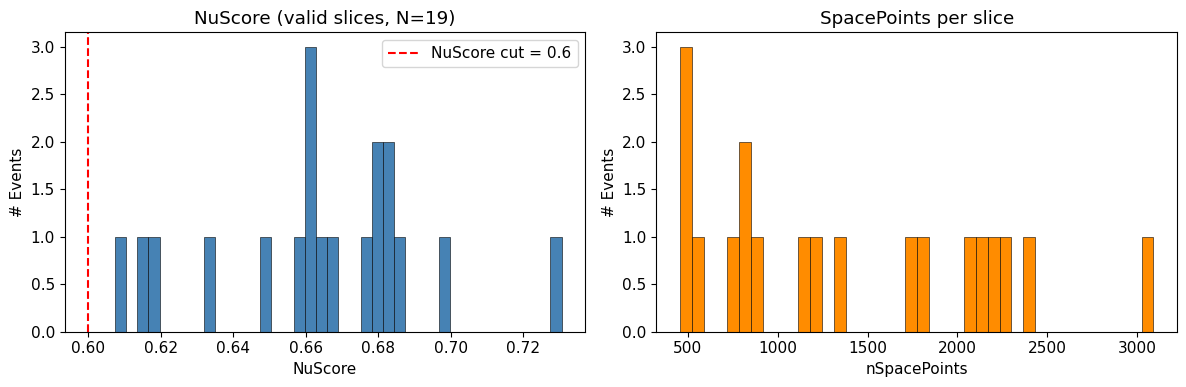

In [4]:
df_valid = df_slice[df_slice['sliceNuScore'] > PLACEHOLDER]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_valid['sliceNuScore'], bins=40, color='steelblue', edgecolor='k', linewidth=0.4)
axes[0].axvline(0.6, color='red', linestyle='--', label='NuScore cut = 0.6')
axes[0].set_xlabel('NuScore')
axes[0].set_ylabel('# Events')
axes[0].set_title(f'NuScore (valid slices, N={len(df_valid)})')
axes[0].legend()

axes[1].hist(df_valid['nSpacePoints'], bins=40, color='darkorange', edgecolor='k', linewidth=0.4)
axes[1].set_xlabel('nSpacePoints')
axes[1].set_ylabel('# Events')
axes[1].set_title('SpacePoints per slice')

plt.tight_layout()
plt.show()

## 4. Predicciones ResNet — distribuciones (sin placeholders)

Events with valid ResNet: 19 / 19


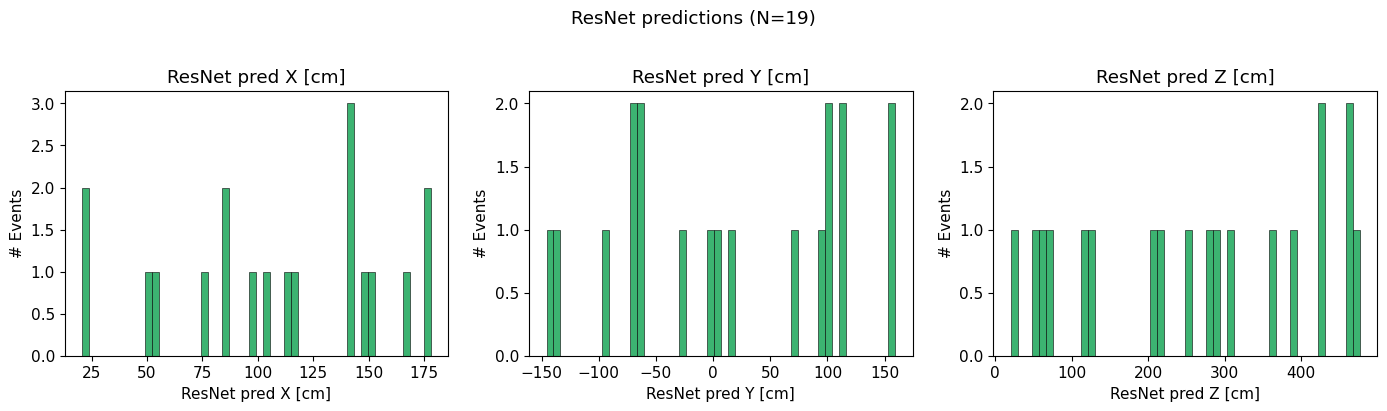

In [5]:
df_inf_ok = df_inf[df_inf['pred_x'] > PLACEHOLDER]
print(f'Events with valid ResNet: {len(df_inf_ok)} / {len(df_inf)}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (col, label) in zip(axes, [('pred_x','X [cm]'),('pred_y','Y [cm]'),('pred_z','Z [cm]')]):
    ax.hist(df_inf_ok[col], bins=50, color='mediumseagreen', edgecolor='k', linewidth=0.4)
    ax.set_xlabel(f'ResNet pred {label}')
    ax.set_ylabel('# Events')
    ax.set_title(f'ResNet pred {label}')

plt.suptitle(f'ResNet predictions (N={len(df_inf_ok)})', y=1.02)
plt.tight_layout()
plt.show()

## 5. Merge ResNet + Pandora/CNN

**Nota X:** ResNet no distingue TPC → predice siempre |X|.  
El residuo en X se calcula como `|pred_x| − |vtxX|`.

In [6]:
df = pd.merge(
    df_inf[['run','subrun','event','pred_x','pred_y','pred_z',
            'pred_dir_y','pred_dir_z','selected_tpc']],
    df_slice,
    on=['run','subrun','event'],
    how='inner'
)

# Exclude ResNet placeholders (pred_x == −999)
df = df[df['pred_x'] > PLACEHOLDER].copy()
print(f'Events after merge (valid ResNet): {len(df)}')

# Residuals ResNet vs Pandora vertex (X: TPC-agnostic → absolute values)
df['res_x']  = np.abs(df['pred_x']) - np.abs(df['vtxX'])
df['res_y']  = df['pred_y'] - df['vtxY']
df['res_z']  = df['pred_z'] - df['vtxZ']
df['res_3d'] = np.sqrt(df['res_x']**2 + df['res_y']**2 + df['res_z']**2)

display(df[['pred_x','vtxX','res_x','pred_y','vtxY','res_y','pred_z','vtxZ','res_z','res_3d']].head(4))

Events after merge (valid ResNet): 19


,pred_x,vtxX,res_x,pred_y,vtxY,res_y,pred_z,vtxZ,res_z,res_3d
0,85.429168,-89.022690,-3.593522,-69.389427,-46.343678,-23.045749,428.343773,344.055847,84.287926,87.455557
1,178.086889,-144.662933,33.423955,-136.295366,-133.781982,-2.513384,476.764441,466.507446,10.256994,35.052587
2,105.681658,97.873596,7.808062,-145.628977,-154.160248,8.531271,280.764759,173.485382,107.279377,107.900941
3,140.950203,167.337341,-26.387138,115.804613,91.425255,24.379358,250.597149,335.458282,-84.861133,92.152298


## 6. ResNet vs Pandora vertex

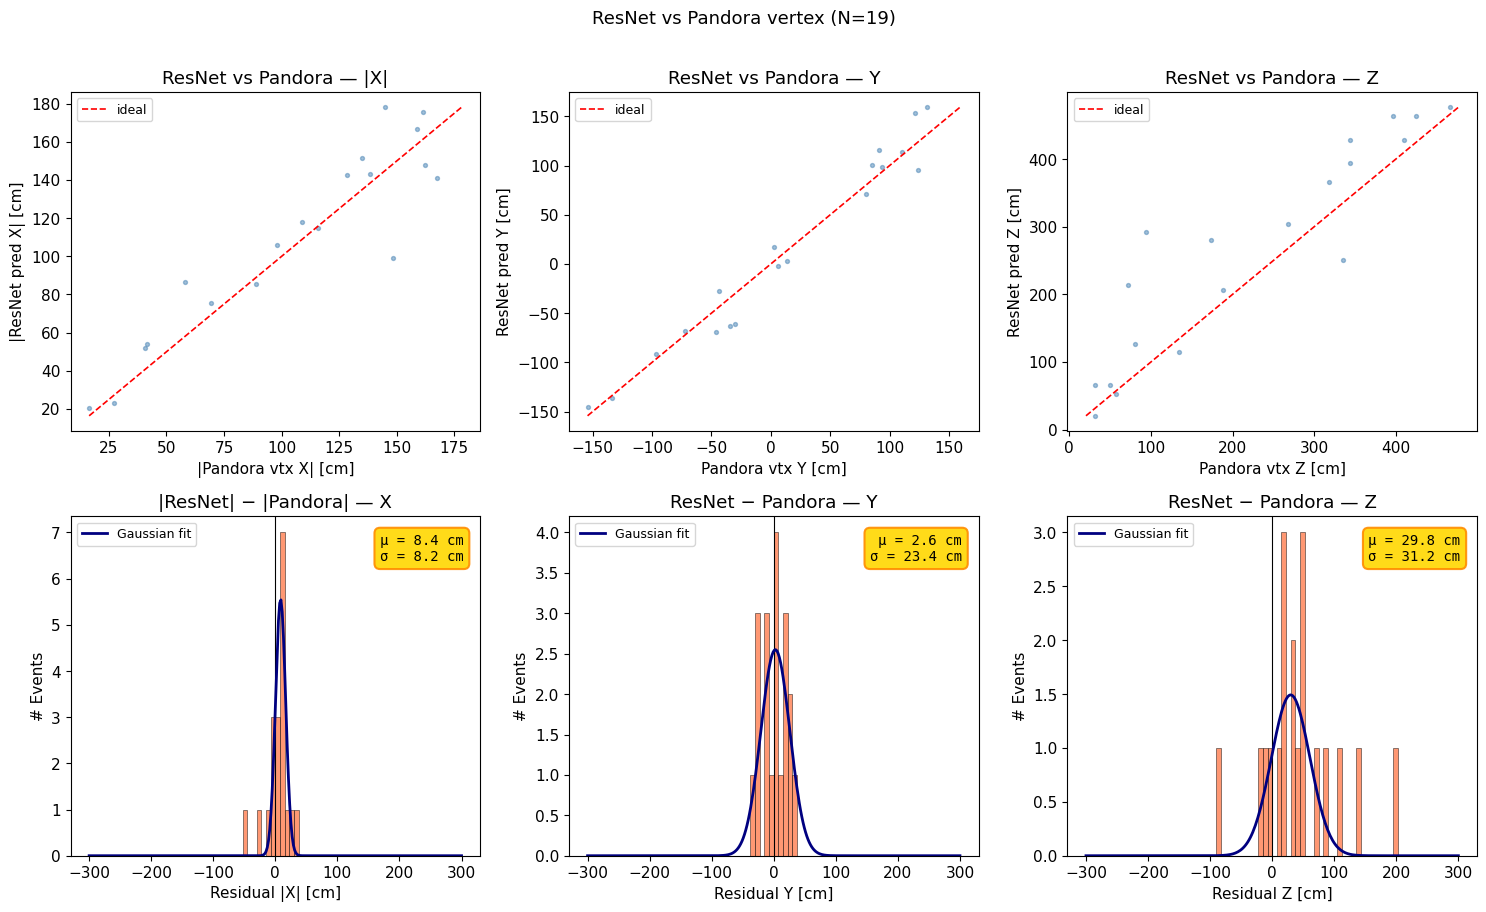

Residual 3D: mean=63.3 cm | median=47.0 cm | std=47.0 cm


In [7]:
FIT_RANGE = (-300, 300)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

scatter_cfg = [
    (np.abs(df['vtxX']), np.abs(df['pred_x']), '|Pandora vtx X| [cm]', '|ResNet pred X| [cm]', 'ResNet vs Pandora — |X|'),
    (df['vtxY'], df['pred_y'],                  'Pandora vtx Y [cm]',   'ResNet pred Y [cm]',   'ResNet vs Pandora — Y'),
    (df['vtxZ'], df['pred_z'],                  'Pandora vtx Z [cm]',   'ResNet pred Z [cm]',   'ResNet vs Pandora — Z'),
]
for i, (xv, yv, xl, yl, title) in enumerate(scatter_cfg):
    ax = axes[i]
    ax.scatter(xv, yv, s=8, alpha=0.5, color='steelblue')
    lims = [min(xv.min(), yv.min()), max(xv.max(), yv.max())]
    ax.plot(lims, lims, 'r--', lw=1.2, label='ideal')
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(title)
    ax.legend(fontsize=9)

res_cfg = [
    ('res_x', 'Residual |X| [cm]', '|ResNet| − |Pandora| — X'),
    ('res_y', 'Residual Y [cm]',   'ResNet − Pandora — Y'),
    ('res_z', 'Residual Z [cm]',   'ResNet − Pandora — Z'),
]
for i, (col, xl, title) in enumerate(res_cfg):
    ax = axes[i+3]
    vals = df[col].values
    counts, bins, _ = ax.hist(vals, bins=80, range=FIT_RANGE,
                               color='coral', edgecolor='k', linewidth=0.4, alpha=0.8)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    ax.axvline(0, color='k', lw=0.8)
    try:
        popt, _ = curve_fit(gaussian, bin_centers, counts,
                            p0=[counts.max(), np.median(vals), np.std(vals)], maxfev=5000)
        x_fit = np.linspace(*FIT_RANGE, 300)
        ax.plot(x_fit, gaussian(x_fit, *popt), 'navy', lw=2, label='Gaussian fit')
        mu, sigma = popt[1], abs(popt[2])
    except Exception:
        mu, sigma = np.mean(vals), np.std(vals)
    ax.set_xlabel(xl); ax.set_ylabel('# Events'); ax.set_title(title)
    ax.legend(fontsize=9)
    ax.text(0.96, 0.95, f'μ = {mu:.1f} cm\nσ = {sigma:.1f} cm',
            transform=ax.transAxes, fontsize=10, va='top', ha='right', family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='gold', edgecolor='darkorange', linewidth=1.5, alpha=0.9))

plt.suptitle(f'ResNet vs Pandora vertex (N={len(df)})', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Residual 3D: mean={df['res_3d'].mean():.1f} cm | median={df['res_3d'].median():.1f} cm | std={df['res_3d'].std():.1f} cm")

## 7. ResNet vs Charge Barycenter

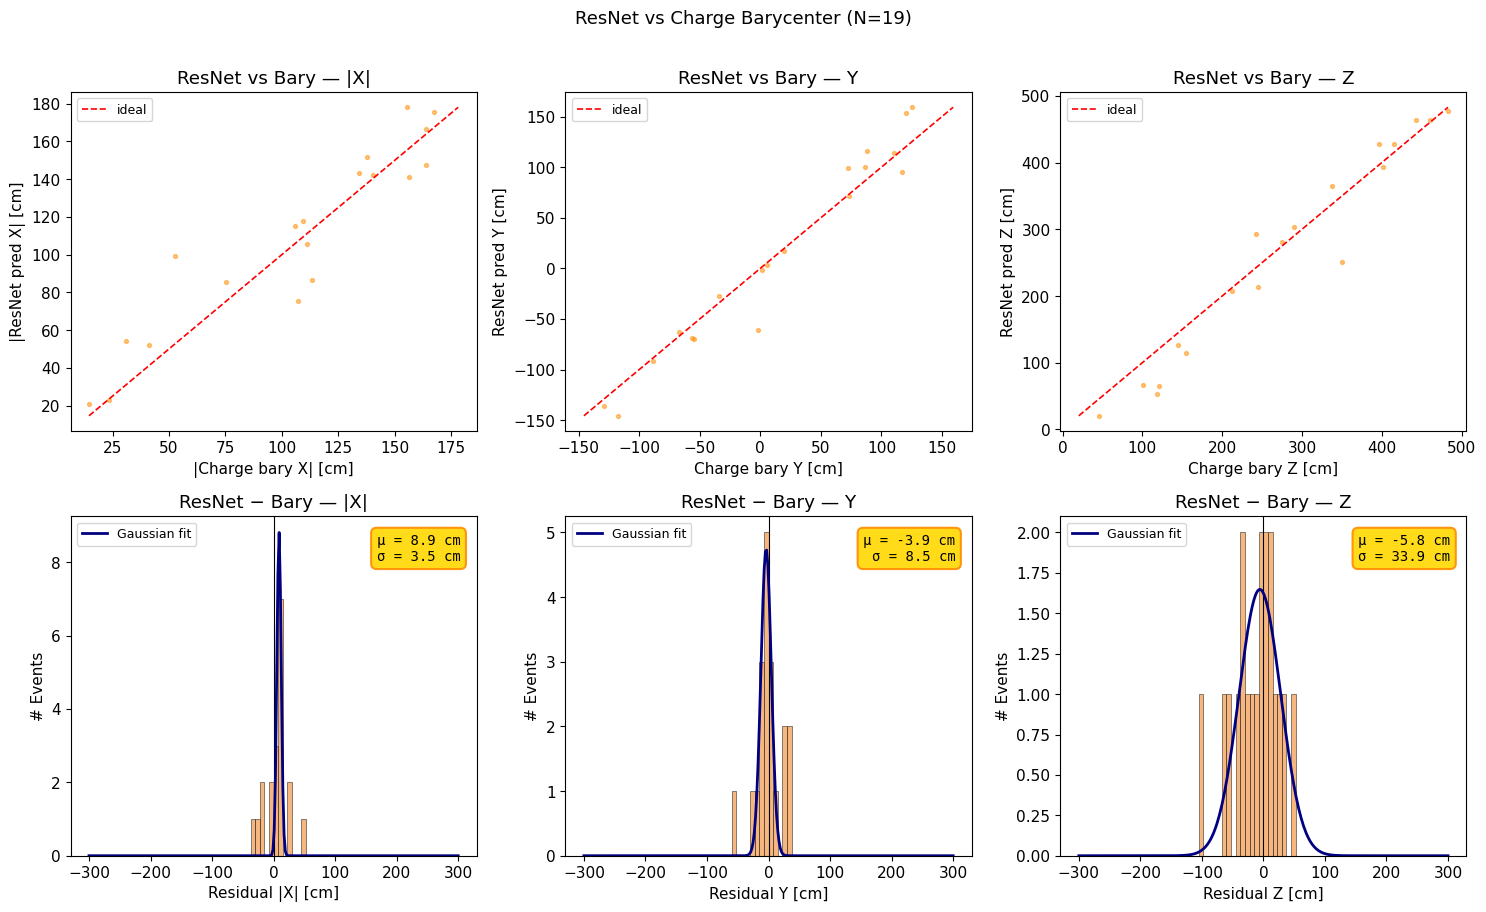

Residual 3D ResNet-Bary: mean=39.6 cm | median=29.6 cm | std=26.7 cm


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

scatter_bary = [
    (np.abs(df['spBaryX']), np.abs(df['pred_x']), '|Charge bary X| [cm]', '|ResNet pred X| [cm]', 'ResNet vs Bary — |X|'),
    (df['spBaryY'], df['pred_y'],                  'Charge bary Y [cm]',   'ResNet pred Y [cm]',   'ResNet vs Bary — Y'),
    (df['spBaryZ'], df['pred_z'],                  'Charge bary Z [cm]',   'ResNet pred Z [cm]',   'ResNet vs Bary — Z'),
]
for i, (xv, yv, xl, yl, title) in enumerate(scatter_bary):
    ax = axes[i]
    ax.scatter(xv, yv, s=8, alpha=0.5, color='darkorange')
    lims = [min(xv.min(), yv.min()), max(xv.max(), yv.max())]
    ax.plot(lims, lims, 'r--', lw=1.2, label='ideal')
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(title)
    ax.legend(fontsize=9)

df['bary_res_x']  = np.abs(df['pred_x']) - np.abs(df['spBaryX'])
df['bary_res_y']  = df['pred_y'] - df['spBaryY']
df['bary_res_z']  = df['pred_z'] - df['spBaryZ']
df['bary_res_3d'] = np.sqrt(df['bary_res_x']**2 + df['bary_res_y']**2 + df['bary_res_z']**2)

res_bary = [
    ('bary_res_x', 'Residual |X| [cm]', 'ResNet − Bary — |X|'),
    ('bary_res_y', 'Residual Y [cm]',   'ResNet − Bary — Y'),
    ('bary_res_z', 'Residual Z [cm]',   'ResNet − Bary — Z'),
]
for i, (col, xl, title) in enumerate(res_bary):
    ax = axes[i+3]
    vals = df[col].values
    counts, bins, _ = ax.hist(vals, bins=80, range=FIT_RANGE,
                               color='sandybrown', edgecolor='k', linewidth=0.4, alpha=0.8)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    ax.axvline(0, color='k', lw=0.8)
    try:
        popt, _ = curve_fit(gaussian, bin_centers, counts,
                            p0=[counts.max(), np.median(vals), np.std(vals)], maxfev=5000)
        x_fit = np.linspace(*FIT_RANGE, 300)
        ax.plot(x_fit, gaussian(x_fit, *popt), 'navy', lw=2, label='Gaussian fit')
        mu, sigma = popt[1], abs(popt[2])
    except Exception:
        mu, sigma = np.mean(vals), np.std(vals)
    ax.set_xlabel(xl); ax.set_ylabel('# Events'); ax.set_title(title)
    ax.legend(fontsize=9)
    ax.text(0.96, 0.95, f'μ = {mu:.1f} cm\nσ = {sigma:.1f} cm',
            transform=ax.transAxes, fontsize=10, va='top', ha='right', family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='gold', edgecolor='darkorange', linewidth=1.5, alpha=0.9))

plt.suptitle(f'ResNet vs Charge Barycenter (N={len(df)})', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Residual 3D ResNet-Bary: mean={df['bary_res_3d'].mean():.1f} cm | median={df['bary_res_3d'].median():.1f} cm | std={df['bary_res_3d'].std():.1f} cm")

## 8. Angle ResNet 2D direction vs Charge SpacePoint PCA (YZ plane)

ResNet predicts a **2D direction in YZ**: `(pred_dir_y, pred_dir_z)`.  
The charge SpacePoint PCA gives a **3D direction**: `(spPCAx, spPCAy, spPCAz)` — charge-weighted.  
We project the PCA onto YZ and compute the angle. Since PCA direction is ambiguous (±), we take `min(θ, 180°−θ)`.

Events with valid pred_dir: 58 / 58


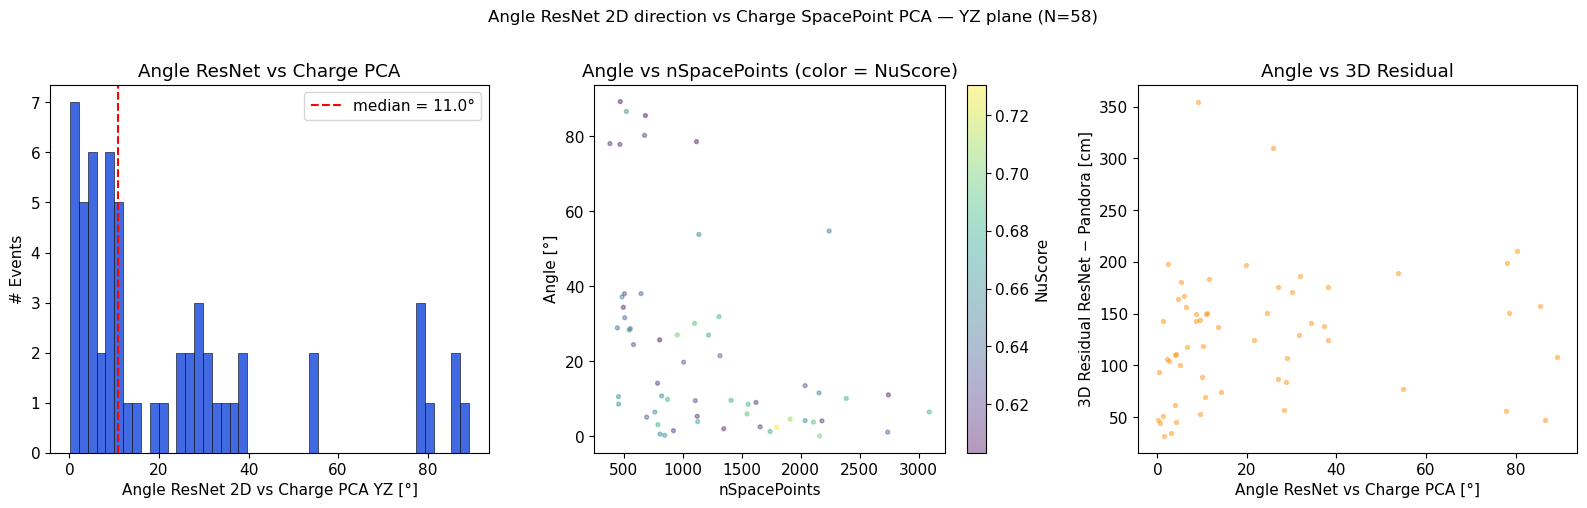

Angle — mean=23.5° | median=11.0° | std=25.5°
Events with angle < 20°: 34 (58.6%)
Events with angle < 45°: 49 (84.5%)


In [9]:
# Filter events with valid pred_dir
df_dir = df[df['pred_dir_y'] > PLACEHOLDER].copy()
print(f'Events with valid pred_dir: {len(df_dir)} / {len(df)}')

# ResNet 2D unit vector (already normalised)
v_rn = np.column_stack([df_dir['pred_dir_y'].values, df_dir['pred_dir_z'].values])

# Charge PCA projected onto YZ and normalised
pca_yz = np.column_stack([df_dir['spPCAy'].values, df_dir['spPCAz'].values])
pca_norm = np.linalg.norm(pca_yz, axis=1, keepdims=True)
pca_norm = np.where(pca_norm == 0, 1, pca_norm)
v_pca = pca_yz / pca_norm

# Angle between v_rn and v_pca
cos_ang = np.clip(np.sum(v_rn * v_pca, axis=1), -1, 1)
angle_deg = np.degrees(np.arccos(cos_ang))
# Direction ambiguity: take minimum angle
angle_deg = np.minimum(angle_deg, 180 - angle_deg)
df_dir['angle_resnet_pca'] = angle_deg

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Angle distribution
axes[0].hist(angle_deg, bins=45, color='royalblue', edgecolor='k', linewidth=0.4)
axes[0].axvline(np.median(angle_deg), color='red', linestyle='--',
                label=f'median = {np.median(angle_deg):.1f}°')
axes[0].set_xlabel('Angle ResNet 2D vs Charge PCA YZ [°]')
axes[0].set_ylabel('# Events')
axes[0].set_title('Angle ResNet vs Charge PCA')
axes[0].legend()

# Angle vs nSpacePoints
sc = axes[1].scatter(df_dir['nSpacePoints'], angle_deg,
                     s=8, alpha=0.4, c=df_dir['sliceNuScore'], cmap='viridis')
plt.colorbar(sc, ax=axes[1], label='NuScore')
axes[1].set_xlabel('nSpacePoints')
axes[1].set_ylabel('Angle [°]')
axes[1].set_title('Angle vs nSpacePoints (color = NuScore)')

# Angle vs 3D residual
axes[2].scatter(angle_deg, df_dir['res_3d'], s=8, alpha=0.4, color='darkorange')
axes[2].set_xlabel('Angle ResNet vs Charge PCA [°]')
axes[2].set_ylabel('3D Residual ResNet − Pandora [cm]')
axes[2].set_title('Angle vs 3D Residual')

plt.suptitle(f'Angle ResNet 2D direction vs Charge SpacePoint PCA — YZ plane (N={len(df_dir)})', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(f"Angle — mean={angle_deg.mean():.1f}° | median={np.median(angle_deg):.1f}° | std={angle_deg.std():.1f}°")
print(f"Events with angle < 20°: {(angle_deg < 20).sum()} ({(angle_deg < 20).sum()/len(angle_deg)*100:.1f}%)")
print(f"Events with angle < 45°: {(angle_deg < 45).sum()} ({(angle_deg < 45).sum()/len(angle_deg)*100:.1f}%)")

## 9. NuScore vs residual 3D

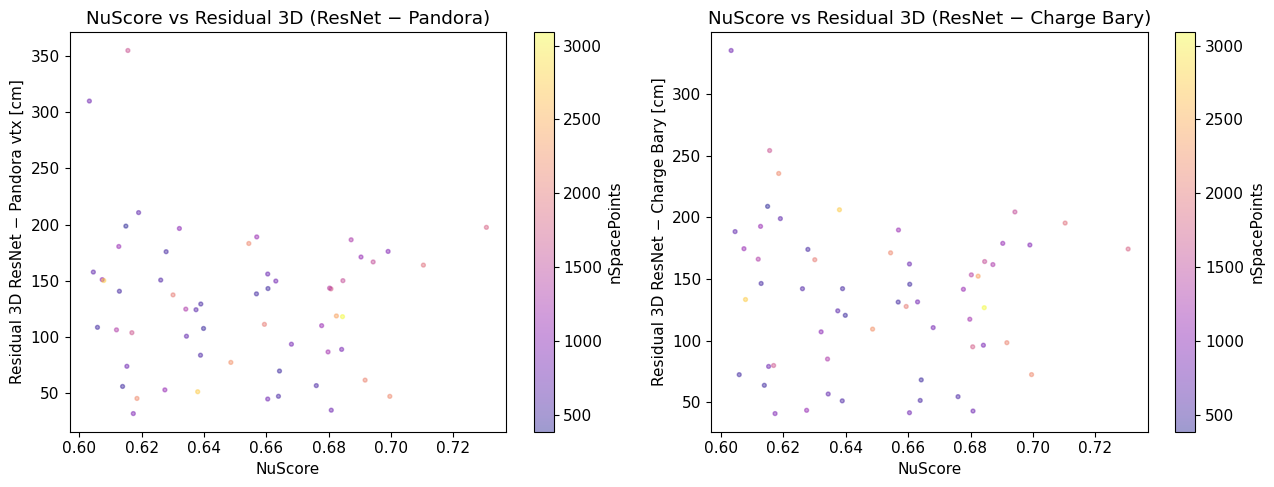

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc1 = axes[0].scatter(df['sliceNuScore'], df['res_3d'],
                      s=8, alpha=0.4, c=df['nSpacePoints'], cmap='plasma')
plt.colorbar(sc1, ax=axes[0], label='nSpacePoints')
axes[0].set_xlabel('NuScore')
axes[0].set_ylabel('Residual 3D ResNet − Pandora vtx [cm]')
axes[0].set_title('NuScore vs Residual 3D (ResNet − Pandora)')

sc2 = axes[1].scatter(df['sliceNuScore'], df['bary_res_3d'],
                      s=8, alpha=0.4, c=df['nSpacePoints'], cmap='plasma')
plt.colorbar(sc2, ax=axes[1], label='nSpacePoints')
axes[1].set_xlabel('NuScore')
axes[1].set_ylabel('Residual 3D ResNet − Charge Bary [cm]')
axes[1].set_title('NuScore vs Residual 3D (ResNet − Charge Bary)')

plt.tight_layout()
plt.show()

## 10. ResNet spatial distribution (ZX and ZY planes)

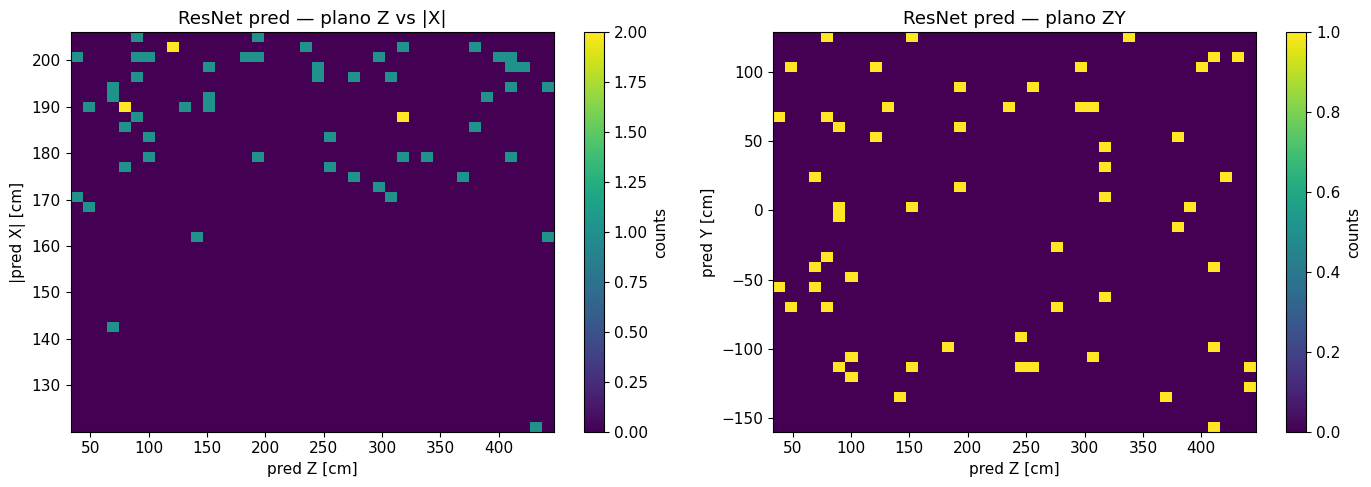

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

h1 = axes[0].hist2d(df['pred_z'], np.abs(df['pred_x']), bins=40, cmap='viridis')
plt.colorbar(h1[3], ax=axes[0], label='counts')
axes[0].set_xlabel('pred Z [cm]'); axes[0].set_ylabel('|pred X| [cm]')
axes[0].set_title('ResNet pred — plano Z vs |X|')

h2 = axes[1].hist2d(df['pred_z'], df['pred_y'], bins=40, cmap='viridis')
plt.colorbar(h2[3], ax=axes[1], label='counts')
axes[1].set_xlabel('pred Z [cm]'); axes[1].set_ylabel('pred Y [cm]')
axes[1].set_title('ResNet pred — plano ZY')

plt.tight_layout()
plt.show()